In [ ]:
#!/bin/bash
!kaggle datasets download yasserh/titanic-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
titanic-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/titanic-dataset.zip

Archive:  /content/titanic-dataset.zip
replace Titanic-Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1, inplace = True)

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
X = df.drop('Survived', axis = 1)
y  = df['Survived']

print(X)
print(y)

     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         3    male  22.0      1      0   7.2500        S
1         1  female  38.0      1      0  71.2833        C
2         3  female  26.0      0      0   7.9250        S
3         1  female  35.0      1      0  53.1000        S
4         3    male  35.0      0      0   8.0500        S
..      ...     ...   ...    ...    ...      ...      ...
886       2    male  27.0      0      0  13.0000        S
887       1  female  19.0      0      0  30.0000        S
888       3  female   NaN      1      2  23.4500        S
889       1    male  26.0      0      0  30.0000        C
890       3    male  32.0      0      0   7.7500        Q

[891 rows x 7 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True, stratify = y)

In [ ]:
y_train.value_counts()

,count
Survived,
0,439
1,273


In [ ]:
y_test.value_counts()

,count
Survived,
0,110
1,69


In [ ]:
import numpy as np
X_nums = X_train.select_dtypes(include = np.number).columns
X_cat = X_train.select_dtypes(exclude = np.number).columns

In [ ]:
X_nums

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [ ]:
X_cat

Index(['Sex', 'Embarked'], dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [ ]:
X_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'Missing')),
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

In [ ]:
X_cat_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='Missing', strategy='constant')),
                ('one-hot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
X_num_pipeline  = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

In [ ]:
X_num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
transformer = ColumnTransformer([
    ('num', X_num_pipeline, X_nums),
    ('cat', X_cat_pipeline, X_cat)
], remainder = 'passthrough')

In [ ]:
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant')),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Sex', 'Embarked'], dtype='object'))])

In [ ]:
log_reg = LogisticRegression(C = 100, solver = 'lbfgs', class_weight = 'balanced', max_iter = 100)

full_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('estimator', log_reg)
])

In [ ]:
full_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Embarked'], dtype='object'))])),
                ('estimator',
                 LogisticRegression(C=100, class_weight='balanced'))])

In [ ]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Embarked'], dtype='object'))])),
                ('estimator',
                 LogisticRegression(C=100, class_weight='balanced'))])

In [ ]:
full_pipeline.score(X_test, y_test)

0.8044692737430168

In [ ]:
from sklearn.model_selection import cross_val_predict
y_test_pred = cross_val_predict(full_pipeline, X_test, y_test, cv = 3)

In [ ]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q
...,...,...,...,...,...,...,...
880,2,female,25.0,0,1,26.0000,S
91,3,male,20.0,0,0,7.8542,S
883,2,male,28.0,0,0,10.5000,S
473,2,female,23.0,0,0,13.7917,C


In [ ]:
y_test

,Survived
565,0
160,0
553,1
860,0
241,1
...,...
880,1
91,0
883,0
473,1


In [ ]:
y_test_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0])

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
cm

array([[89, 21],
       [18, 51]])

In [ ]:
from sklearn.metrics import precision_score, recall_score

print('Precision = ', precision_score(y_test, y_test_pred),
      'Recall = ', recall_score(y_test, y_test_pred))

Precision =  0.7083333333333334 Recall =  0.7391304347826086


In [ ]:
from sklearn.metrics import f1_score
f1_score = f1_score(y_test, y_test_pred)

In [ ]:
f1_score

0.723404255319149

In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_test_pred)
acc

0.7821229050279329

In [ ]:
some_digit = X_test.iloc[[0]]
y_scores = full_pipeline.decision_function(some_digit)
y_scores

array([-2.1177413])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
# from sklearn.metrics import cross_val_predict
y_scores_all = cross_val_predict(full_pipeline, X_test, y_test, cv = 3,
                                 method = 'decision_function')
print(
    'min = ', y_scores_all.min(),
    'mean = ', y_scores_all.mean(),
    'max = ', y_scores_all.max()
)

min =  -7.412395639099332 mean =  -0.1596990812584512 max =  8.137236515007698


In [ ]:
threshold = y_scores_all.mean()
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_all)

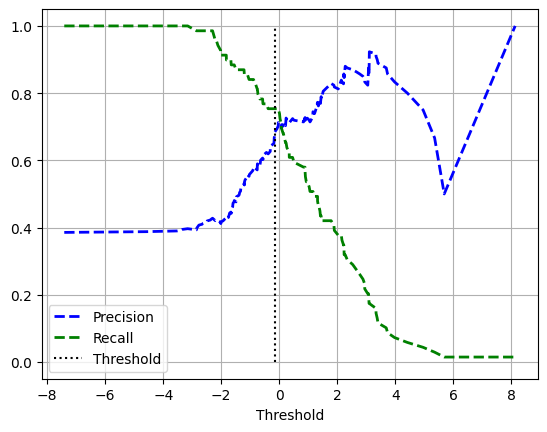

In [ ]:
import matplotlib.pyplot as plt

threshold = y_scores_all.mean()
plt.plot(thresholds, precisions[:-1], 'b--', label = 'Precision', linewidth = 2)
plt.plot(thresholds, recalls[:-1], 'g--', label = 'Recall', linewidth = 2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label = 'Threshold')
plt.xlabel('Threshold')
plt.legend()
plt.grid(True)
plt.show()

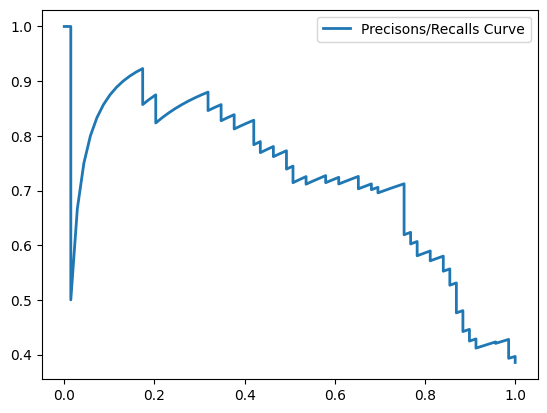

In [ ]:
plt.plot(recalls, precisions, linewidth = 2, label = 'Precisons/Recalls Curve')
plt.legend()
plt.show()